# Behavioral Metrics

Three metrics characterise agent behavior: **Directness** (time efficiency relative to the Dijkstra corridor),
**Risk Exposure** (Ulcer Index of the survival budget), and **Exploration** (coverage of land cells).
Each is illustrated with a synthetic high/low trajectory pair.

In [166]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import torch
import matplotlib.pyplot as plt
from cogniland.env.types import EnvConfig, RewardConfig, TerrainDef

# ── Terrain table (matches configs/env/default.yaml) ──
TERRAINS = (
    TerrainDef("ocean",      0.007, 1.0,  -1.0, 0.0, 16, (5,35,225),     ("water",)),
    TerrainDef("deep_water", 0.025, 1.25, -0.5, 0.0, 12, (25,65,225),    ("water",)),
    TerrainDef("water",      0.05,  1.5,  -0.2, 0.0, 10, (65,105,225),   ("water",)),
    TerrainDef("beach",      0.06,  1.75, -1.0, 0.0,  7, (238,214,175),  ("land",)),
    TerrainDef("sandy",      0.1,   2.0,  -1.0, 0.0,  7, (210,180,140),  ("land",)),
    TerrainDef("grassland",  0.25,  2.25, -1.0, 0.0,  7, (34,139,34),    ("land",)),
    TerrainDef("forest",     0.6,   3.0,   5.0, 5.0,  5, (0,100,0),      ("land","forest")),
    TerrainDef("rocky",      0.7,   3.5,  -2.0, 0.0, 10, (139,137,137),  ("land",)),
    TerrainDef("mountains",  1.0,   4.0,  -5.0, 0.0, 22, (255,250,250),  ("land",)),
)

config = EnvConfig(
    terrains=TERRAINS,
    reward=RewardConfig(reach_bonus=150.0, lambda_p=0.3, lambda_s=0.02,
                        lambda_t=100.0, lambda_d=0.10, beta_raft=20.0),
)
compiled = config.compile_terrain("cpu")

# ── Load a validation map ──
val_maps = torch.load("../data/val_seed42_n16.pt", map_location="cpu",
                       weights_only=True)["maps"]
hmap = val_maps[0]  # [250, 250]
H, W = hmap.shape

# ── Precompute numpy arrays ──
thresholds_np = compiled.thresholds.numpy()
color_lut     = compiled.color_lut.numpy()
move_costs_np = compiled.move_costs.numpy()
res_rate_np   = compiled.res_rate.numpy()
is_water_np   = compiled.is_water.numpy()
is_forest_np  = compiled.is_forest.numpy()
vis_np        = compiled.visibility.numpy()

def terrain_idx_map(hm):
    t = np.searchsorted(thresholds_np, hm.numpy().ravel(), side="left").reshape(hm.shape)
    return np.clip(t, 0, compiled.num_terrains - 1)

def colorize(hm):
    return color_lut[terrain_idx_map(hm)]

tmap = terrain_idx_map(hmap)
rgb  = colorize(hmap)

# ── Resource-aware Dijkstra (for cost-to-go path tracing) ──
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra as scipy_dijkstra

def build_graph(wm_np, terrains, beta_raft):
    H, W = wm_np.shape
    th = np.array([t.threshold for t in terrains])
    iw = np.array(["water" in t.tags for t in terrains])
    edge_costs = np.array([max(0.1, t.move_cost - t.res_rate) for t in terrains])
    terrain = np.clip(np.searchsorted(th, wm_np.ravel(), side="left").reshape(H, W),
                      0, len(th) - 1).astype(np.int32)
    water_mask = iw[terrain]
    r_h, c_h = np.mgrid[0:H, 0:W-1]
    src_h = (r_h * W + c_h).ravel()
    dst_h = (r_h * W + c_h + 1).ravel()
    cost_h_fwd = edge_costs[terrain[r_h, c_h + 1]].ravel()
    raft_h_fwd = (~water_mask[r_h, c_h] & water_mask[r_h, c_h + 1]).ravel().astype(float) * beta_raft
    cost_h_bwd = edge_costs[terrain[r_h, c_h]].ravel()
    raft_h_bwd = (~water_mask[r_h, c_h + 1] & water_mask[r_h, c_h]).ravel().astype(float) * beta_raft
    r_v, c_v = np.mgrid[0:H-1, 0:W]
    src_v = (r_v * W + c_v).ravel()
    dst_v = ((r_v + 1) * W + c_v).ravel()
    cost_v_fwd = edge_costs[terrain[r_v + 1, c_v]].ravel()
    raft_v_fwd = (~water_mask[r_v, c_v] & water_mask[r_v + 1, c_v]).ravel().astype(float) * beta_raft
    cost_v_bwd = edge_costs[terrain[r_v, c_v]].ravel()
    raft_v_bwd = (~water_mask[r_v + 1, c_v] & water_mask[r_v, c_v]).ravel().astype(float) * beta_raft
    all_src  = np.concatenate([src_h, dst_h, src_v, dst_v])
    all_dst  = np.concatenate([dst_h, src_h, dst_v, src_v])
    all_data = np.concatenate([
        cost_h_fwd + raft_h_fwd, cost_h_bwd + raft_h_bwd,
        cost_v_fwd + raft_v_fwd, cost_v_bwd + raft_v_bwd,
    ])
    return csr_matrix((all_data, (all_src, all_dst)), shape=(H*W, H*W))

SPAWN  = (130, 75)
TARGET = (80, 125)

graph = build_graph(hmap.numpy(), TERRAINS, config.reward.beta_raft)
ctg   = scipy_dijkstra(graph.T, directed=True,
                        indices=TARGET[0]*W+TARGET[1]).reshape(H, W)

def trace_path(ctg, spawn, target, max_steps=5000):
    DELTAS = [(-1,0),(1,0),(0,1),(0,-1)]
    path = [spawn]; r,c = spawn
    for _ in range(max_steps):
        if (r,c) == target: break
        best, nxt = ctg[r,c], None
        for dr,dc in DELTAS:
            nr,nc = r+dr, c+dc
            if 0<=nr<H and 0<=nc<W and ctg[nr,nc] < best:
                best, nxt = ctg[nr,nc], (nr,nc)
        if nxt is None: break
        r,c = nxt; path.append((r,c))
    return path

optimal_path = trace_path(ctg, SPAWN, TARGET)
print(f"Optimal path: {len(optimal_path)} steps")

Optimal path: 101 steps


## 1. Directness (Time Efficiency)

$T = \frac{t^*}{t_{\text{agent}}} \in [0, 1]$

where $t^*$ is the Dijkstra shortest-time cost (using `move_cost` only) and $t_{\text{agent}}$ is the
agent's actual cumulative traversal time. Detours, backtracking, and foraging all reduce $T$.
**High** = time-optimal; **Low** = slow relative to shortest path.

t* = 162.2,  direct = 171.2 (T=0.947),  wobbly = 313.0 (T=0.518)


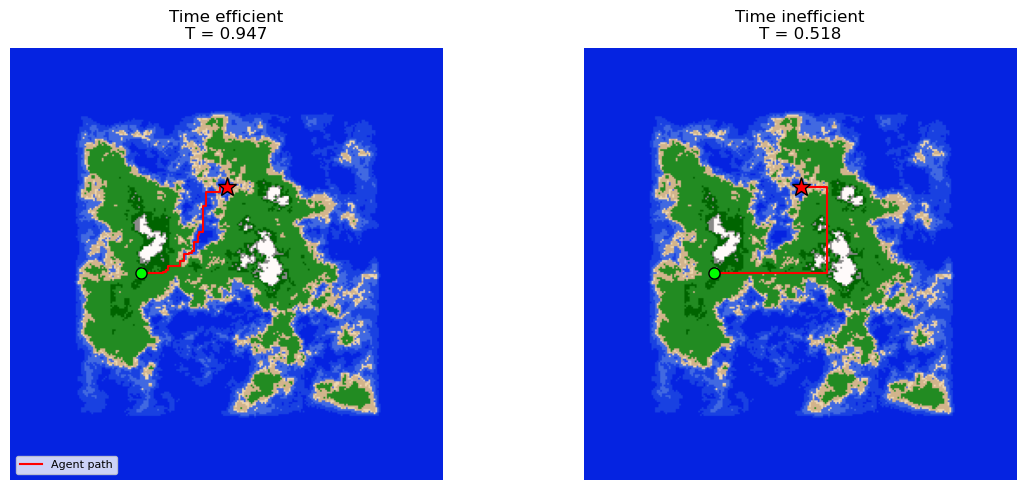

In [171]:
# ── Compute optimal time cost via Dijkstra (move_cost edges only) ──
def build_time_graph(wm_np, terrains):
    """Dijkstra graph with edge weight = move_cost of destination terrain."""
    H, W = wm_np.shape
    th = np.array([t.threshold for t in terrains])
    mc = np.array([t.move_cost for t in terrains])
    ti = np.clip(np.searchsorted(th, wm_np.ravel(), side="left").reshape(H, W),
                 0, len(th) - 1).astype(np.int32)
    r_h, c_h = np.mgrid[0:H, 0:W-1]
    src_h = (r_h * W + c_h).ravel()
    dst_h = (r_h * W + c_h + 1).ravel()
    r_v, c_v = np.mgrid[0:H-1, 0:W]
    src_v = (r_v * W + c_v).ravel()
    dst_v = ((r_v + 1) * W + c_v).ravel()
    all_src  = np.concatenate([src_h, dst_h, src_v, dst_v])
    all_dst  = np.concatenate([dst_h, src_h, dst_v, src_v])
    all_data = np.concatenate([
        mc[ti[r_h, c_h+1]].ravel(), mc[ti[r_h, c_h]].ravel(),
        mc[ti[r_v+1, c_v]].ravel(), mc[ti[r_v, c_v]].ravel(),
    ])
    return csr_matrix((all_data, (all_src, all_dst)), shape=(H*W, H*W))

sr, sc = SPAWN
tr, tc = TARGET

# Forward Dijkstra from SPAWN (time-only edges)
time_graph = build_time_graph(hmap.numpy(), TERRAINS)
time_fwd   = scipy_dijkstra(time_graph, directed=True,
                             indices=sr * W + sc).reshape(H, W)
optimal_time = time_fwd[tr, tc]

# Reverse Dijkstra from TARGET (for greedy tracer)
time_rev = scipy_dijkstra(time_graph.T, directed=True,
                           indices=tr * W + tc).reshape(H, W)

def trace_time_optimal(ctg, spawn, target):
    """Greedy descent on time-only cost-to-go → exact shortest-time path."""
    DELTAS = [(-1,0),(1,0),(0,1),(0,-1)]
    path = [spawn]; r, c = spawn
    for _ in range(H * W):
        if (r, c) == target: break
        best, nxt = ctg[r, c], None
        for dr, dc in DELTAS:
            nr, nc = r + dr, c + dc
            if 0 <= nr < H and 0 <= nc < W and ctg[nr, nc] < best:
                best, nxt = ctg[nr, nc], (nr, nc)
        if nxt is None: break
        r, c = nxt; path.append((r, c))
    return path

def path_time(path, tmap):
    return sum(move_costs_np[tmap[path[t]]] for t in range(1, len(path)))

# ── High directness: time-optimal path (T = 1.0) ──
path_optimal = trace_time_optimal(time_rev, SPAWN, TARGET)
time_opt = path_time(path_optimal, tmap)
T_high = optimal_time / max(time_opt, 1e-6)

# ── Low directness: detour east through grassland, then north, then back to target ──
path_wobbly = [SPAWN]
r, c = sr, sc
east_col = 140
while c != east_col:
    c += 1; path_wobbly.append((r, c))
while r != tr:
    r -= 1; path_wobbly.append((r, c))
while c != tc:
    c -= 1; path_wobbly.append((r, c))

time_wobbly = path_time(path_wobbly, tmap)
T_low = optimal_time / max(time_wobbly, 1e-6)

print(f"t* = {optimal_time:.1f},  direct = {time_opt:.1f} (T={T_high:.3f}),  wobbly = {time_wobbly:.1f} (T={T_low:.3f})")

# ── Plot ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for ax, path, T_val, label in [
    (ax1, path_optimal, T_high, "Time efficient"),
    (ax2, path_wobbly,  T_low,  "Time inefficient"),
]:
    ax.imshow(rgb)
    cols = [c for r, c in path]
    rows = [r for r, c in path]
    ax.plot(cols, rows, "r-", linewidth=1.5, label="Agent path")
    ax.plot(SPAWN[1],  SPAWN[0],  "o", color="lime", ms=8, mec="k")
    ax.plot(TARGET[1], TARGET[0], "r*", ms=14, mec="k")
    ax.set_title(f"{label}\nT = {T_val:.3f}", fontsize=12)
    ax.axis("off")
ax1.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

## 2. Risk Exposure

$u_t = \text{res}_t + \text{hp}_t, \qquad \rho = \sqrt{\frac{1}{T}\sum_{t=1}^{T}\left(\frac{u_0 - u_t}{u_0}\right)^2}$

RMS of relative drawdowns from the initial survival budget $u_0 = 200$.
Three synthetic examples illustrate how different budget profiles produce different $\rho$ values.

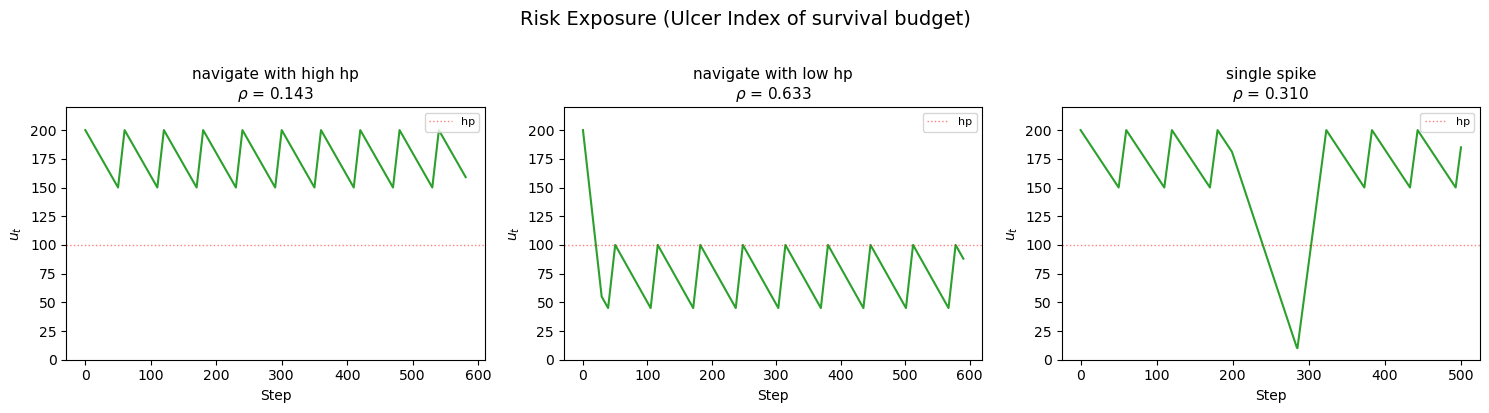

In [168]:
def risk_exposure(u):
    u0 = u[0]
    drawdown = np.maximum(0, (u0 - u) / u0)
    return np.sqrt((drawdown ** 2).mean())

u0 = 200.0

# ── A: sawtooth near the top — drain -1/step to 150, replenish +5/step to 200, repeat ──
u_a = [u0]
for _ in range(500):
    v = u_a[-1]
    if v <= 150:
        while v <= 195:
            u_a.append(min(v + 5, 200))
            v = u_a[-1]
    else:
        u_a.append(v - 1)
u_a = np.array(u_a)

# ── B: fast drop then small wobbles at the bottom ──
u_b = [u0]
for _ in range(500):
    v = u_b[-1]
    if len(u_b) < 30:
        # fast drop
        v -= 5
        u_b.append(v)
    else:
        # sawtooth between 30 and 80
        if v <= 45:
            while v <= 95:
                u_b.append(v + 5)
                v = u_b[-1]
        else:
             u_b.append(v - 1)
            
u_b = np.array(u_b)

# ── C: sawtooth like u_a, drop to 20 at -2/step around step 200, recover at +5, resume sawtooth ──
u_c = [u0]
state = 'sawtooth'
saw_dir = 'drain'  # start draining from u0=200

def saw_step(v, saw_dir):
    """One sawtooth step matching u_a: drain -1 to 150, burst-climb +5 to 200."""
    if saw_dir == 'drain':
        if v <= 150:
            saw_dir = 'climb'
        else:
            v -= 1
    if saw_dir == 'climb':
        if v >= 200:
            saw_dir = 'drain'
            v -= 1
        else:
            v = min(v + 5, 200)
    return v, saw_dir

for _ in range(500):
    v = u_c[-1]

    if state == 'sawtooth' and len(u_c) >= 200:
        state = 'drop'

    if state == 'sawtooth':
        v, saw_dir = saw_step(v, saw_dir)
    elif state == 'drop':
        v = max(v - 2, 10)
        if v <= 10:
            state = 'recover'
    elif state == 'recover':
        v = min(v + 5, 200)
        if v >= 150:
            state = 'sawtooth_post'
            saw_dir = 'climb'  # already climbing back up
    else:  # sawtooth_post
        v, saw_dir = saw_step(v, saw_dir)

    u_c.append(v)

u_c = np.array(u_c)

rho_a = risk_exposure(u_a)
rho_b = risk_exposure(u_b)
rho_c = risk_exposure(u_c)

# ── Plot ──
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
for ax, u, rho, label in [
    (ax1, u_a, rho_a, "navigate with high hp"),
    (ax2, u_b, rho_b, "navigate with low hp"),
    (ax3, u_c, rho_c, "single spike"),
]:
    ax.plot(np.arange(len(u)), u, color="tab:green", lw=1.5)
    ax.axhline(100, ls=":", color="red", alpha=0.5, lw=1, label="hp")
    ax.set_ylim(0, u0 + 20)
    ax.set_xlabel("Step")
    ax.set_ylabel("$u_t$")
    ax.set_title(f"{label}\n$\\rho$ = {rho:.3f}", fontsize=11)
    ax.legend(loc="upper right", fontsize=8)
fig.suptitle("Risk Exposure (Ulcer Index of survival budget)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Exploration (Coverage)

$C = \frac{|\mathcal{C}_{\text{obs}} \cap \mathcal{L}|}{|\mathcal{L}|} \in [0,1]$

where $\mathcal{L}$ is the set of land cells on the map and $\mathcal{C}_{\text{obs}}$
is the set of cells observed at least once during the episode. $C$ measures the fraction of land tiles the agent has seen, accounting for occlusion.
**High** = agent covered most of the land; **Low** = agent saw only a small portion.

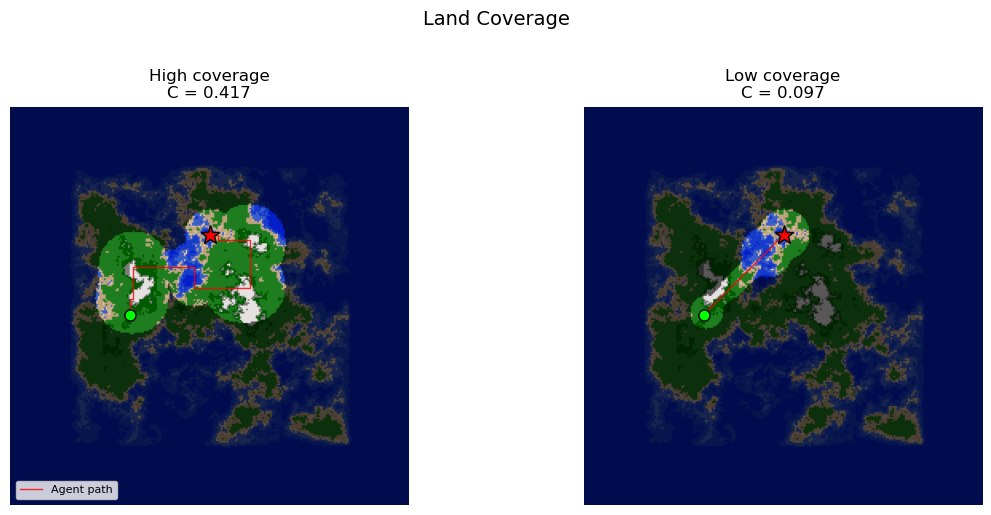

In [169]:
def accumulate_vis_counts(path, tmap, vis_table, map_shape):
    """Accumulate per-cell visibility counts along a path (no occlusion for simplicity)."""
    H, W = map_shape
    counts = np.zeros((H, W), dtype=np.int32)
    for r, c in path:
        rad = int(vis_table[tmap[r, c]])
        r0 = max(0, r - rad); r1 = min(H, r + rad + 1)
        c0 = max(0, c - rad); c1 = min(W, c + rad + 1)
        # circular mask
        ys, xs = np.ogrid[r0-r:r1-r, c0-c:c1-c]
        mask = (ys**2 + xs**2) <= rad**2
        counts[r0:r1, c0:c1] += mask.astype(np.int32)
    return counts

def land_coverage(counts, land_mask):
    """Coverage: fraction of land cells observed at least once."""
    observed = counts > 0
    land_observed = (observed & land_mask).sum()
    land_total = land_mask.sum()
    if land_total == 0:
        return 0.0
    return land_observed / land_total

# Build land mask from terrain map
land_mask = ~is_water_np[tmap]  # True for non-water cells

def walk_to(path, r, c, tr, tc):
    """Append step-by-step moves from (r,c) to (tr,tc); return new position."""
    while r != tr:
        r += (1 if tr > r else -1)
        path.append((r, c))
    while c != tc:
        c += (1 if tc > c else -1)
        path.append((r, c))
    return r, c

# ── High-exploration: hop on/off mountains, cross an ocean pool ──
path_explore = [SPAWN]
r, c = sr, sc
r, c = walk_to(path_explore, r, c, 120, 77)   # ascend western mountain
r, c = walk_to(path_explore, r, c, 100, 115)  # head east, cross ocean pool
r, c = walk_to(path_explore, r, c, 113, 150)  # ascend eastern mountain
r, c = walk_to(path_explore, r, c, 83, 130)   # head northwest through ocean
r, c = walk_to(path_explore, r, c, tr, tc)    # arrive at TARGET

# ── Low-exploration: straight diagonal through grassland/forest ──
path_narrow = [SPAWN]
r, c = sr, sc
while r > tr:
    r -= 1
    if c < tc:
        c += 1
    path_narrow.append((r, c))
while c != tc:
    c += (1 if tc > c else -1)
    path_narrow.append((r, c))

vc_explore = accumulate_vis_counts(path_explore, tmap, vis_np, (H, W))
vc_narrow  = accumulate_vis_counts(path_narrow,  tmap, vis_np, (H, W))
C_explore = land_coverage(vc_explore, land_mask)
C_narrow  = land_coverage(vc_narrow,  land_mask)

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, path, vc, C_val, label in [
    (axes[0], path_explore, vc_explore, C_explore, "High coverage"),
    (axes[1], path_narrow,  vc_narrow,  C_narrow,  "Low coverage"),
]:
    # Dim the base map, brighten observed cells
    base = rgb.astype(float) * 0.35
    observed = vc > 0
    base[observed] = rgb[observed].astype(float) * 0.9
    ax.imshow(base.astype(np.uint8))
    cols = [c for r, c in path]
    rows = [r for r, c in path]
    ax.plot(cols, rows, "r-", linewidth=1.0, alpha=0.8, label="Agent path")
    ax.plot(SPAWN[1],  SPAWN[0],  "o", color="lime", ms=8, mec="k")
    ax.plot(TARGET[1], TARGET[0], "r*", ms=14, mec="k")
    ax.set_title(f"{label}\nC = {C_val:.3f}", fontsize=12)
    ax.axis("off")
axes[0].legend(loc="lower left", fontsize=8)
fig.suptitle("Land Coverage", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()